## 0. Notebook Purpose

This notebook handles model training, evaluation, comparison, and final interpretation.

Decision: All models are trained using preprocessed data from `data/processed/`. The test set is used only once for final evaluation of the selected model. Comparison metrics are documented in decisions.md before any models are run. Shared utility functions are imported from `src/utils.py`.

In [1]:
# ============================================
# Setup, Imports & Path Configuration
# ============================================
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import pickle
import json
from pathlib import Path

# ============================================
# Sklearn Imports (Required for Modeling)
# ============================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import seaborn as sns

# ============================================
# Robust Project Root Detection
# ============================================
current_dir = Path.cwd()
if (current_dir / "src").exists() and (current_dir / "notebooks").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "src").exists() and (current_dir.parent / "notebooks").exists():
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

# Add project root to sys.path so 'src' can be imported
sys.path.insert(0, str(PROJECT_ROOT))

# Define absolute paths
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# Create directories
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Outputs: {OUTPUTS_DIR}")
print(f"Processed: {PROCESSED_DIR}")

# ============================================
# Import Shared Utilities & Reproducibility
# ============================================
from src.utils import evaluate_top_k, ensure_dir

np.random.seed(42)
random.seed(42)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 120)

print("Setup complete. Modeling libraries imported.")

Project root: /home/azan_khan/NFL-Prediction-Model
Outputs: /home/azan_khan/NFL-Prediction-Model/outputs
Processed: /home/azan_khan/NFL-Prediction-Model/data/processed
Setup complete. Modeling libraries imported.


## 1. Load Preprocessed Data

Decision: Load all preprocessed objects from `data/processed/` (generated by 02_cleaning.ipynb). This ensures the modeling notebook operates on consistent, leakage-free data.

In [2]:
# ============================================
# Load Preprocessed Data
# ============================================

with open(PROJECT_ROOT / "data/processed/X_train_full.pkl", "rb") as f:
    X_train_full = pickle.load(f)
with open(PROJECT_ROOT / "data/processed/X_test_full.pkl", "rb") as f:
    X_test_full = pickle.load(f)
with open(PROJECT_ROOT / "data/processed/y_train.pkl", "rb") as f:
    y_train = pickle.load(f)
with open(PROJECT_ROOT / "data/processed/y_test.pkl", "rb") as f:
    y_test = pickle.load(f)

with open(PROJECT_ROOT / "data/processed/X_train_clean.pkl", "rb") as f:
    X_train_clean = pickle.load(f)
with open(PROJECT_ROOT / "data/processed/X_test_clean.pkl", "rb") as f:
    X_test_clean = pickle.load(f)

with open(PROJECT_ROOT / "data/processed/X_train_full_scaled.pkl", "rb") as f:
    X_train_full_scaled = pickle.load(f)
with open(PROJECT_ROOT / "data/processed/X_test_full_scaled.pkl", "rb") as f:
    X_test_full_scaled = pickle.load(f)
with open(PROJECT_ROOT / "data/processed/X_train_clean_scaled.pkl", "rb") as f:
    X_train_clean_scaled = pickle.load(f)
with open(PROJECT_ROOT / "data/processed/X_test_clean_scaled.pkl", "rb") as f:
    X_test_clean_scaled = pickle.load(f)

with open(PROJECT_ROOT / "data/processed/scaler_full.pkl", "rb") as f:
    scaler_full = pickle.load(f)
with open(PROJECT_ROOT / "data/processed/scaler_clean.pkl", "rb") as f:
    scaler_clean = pickle.load(f)

# Load test dataframe for result annotation
test = pd.read_csv(PROJECT_ROOT / "data/processed/team_stats_with_target.csv")
test = test[test["year"] >= 2019].copy()

print("Preprocessed data loaded successfully.")
print("Test set shape:", X_test_clean.shape)

# ============================================
# FIX: Convert pandas Series to writable numpy arrays
# ============================================
# This resolves pandas 2.2+ / sklearn 1.4+ compatibility issue with read-only arrays
y_train = np.asarray(y_train).ravel()
y_test = np.asarray(y_test).ravel()

print("Target variables converted to writable numpy arrays")

# Assertion: Verify loaded data matches expected shapes
assert X_train_clean.shape[0] + X_test_clean.shape[0] == 672, "Train/test split size mismatch"

Preprocessed data loaded successfully.
Test set shape: (160, 29)
Target variables converted to writable numpy arrays


## 2. Cross-Validated Model Comparison on Training Data

Before using the held-out test set, the two candidate models are compared using **5-fold cross-validated AUC on the training data only**.

Decision: This is important because the test set should be reserved for final evaluation rather than model selection. By comparing models using only the training data, we reduce the risk of choosing a model simply because it happened to perform well on the held-out test seasons.

Comparison metric declared: 5-fold CV AUC (declared before any models run; test set held out).

In [3]:
# ============================================
# Cross-Validated Model Comparison (Training Only)
# ============================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_cv_model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

rf_cv_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

# FIX: Convert y_train to numpy array to avoid pandas/sklearn writeable flag issue
y_train_array = np.asarray(y_train).ravel()

log_cv_auc = cross_val_score(
    log_cv_model,
    X_train_clean_scaled,
    y_train_array,  # Use numpy array instead of pandas Series
    cv=cv,
    scoring="roc_auc"
)

rf_cv_auc = cross_val_score(
    rf_cv_model,
    X_train_clean,
    y_train_array,  # Use numpy array instead of pandas Series
    cv=cv,    scoring="roc_auc"
)

print("Logistic Regression CV AUC scores:", log_cv_auc)
print("Logistic Regression mean CV AUC:", round(log_cv_auc.mean(), 4))
print("Logistic Regression std CV AUC:", round(log_cv_auc.std(), 4))

print()

print("Random Forest CV AUC scores:", rf_cv_auc)
print("Random Forest mean CV AUC:", round(rf_cv_auc.mean(), 4))
print("Random Forest std CV AUC:", round(rf_cv_auc.std(), 4))

Logistic Regression CV AUC scores: [0.91161616 0.77       0.76430976 0.87205387 0.63973064]
Logistic Regression mean CV AUC: 0.7915
Logistic Regression std CV AUC: 0.095

Random Forest CV AUC scores: [0.7979798  0.67833333 0.7962963  0.72390572 0.62121212]
Random Forest mean CV AUC: 0.7235
Random Forest std CV AUC: 0.0683


### Cross-Validation Interpretation

These cross-validated AUC results provide a training-only comparison between the two model families.

Decision: This comparison is used to judge which model appears stronger before looking at the held-out test set. The later test-set results are therefore interpreted as a final evaluation step rather than the basis for choosing the model in the first place.

These results suggest that Logistic Regression is the stronger model based on training-only evaluation, and this will be further validated using the held-out test set.

## 3. Baseline Model: Logistic Regression

Logistic regression is used as the baseline classification model for this project.

Decision: We evaluate two versions: (1) full-feature model with all available predictors, (2) reduced clean-feature model excluding redundant/outcome-based variables. This allows comparison of predictive performance while testing whether a more interpretable feature set can still identify strong contenders.

In [4]:
# ============================================
# Train Logistic Regression (Full Features)
# ============================================

# Decision: Use class_weight='balanced' to address extreme class imbalance
model_full = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42)

model_full.fit(X_train_full_scaled, y_train)

print("Full model trained.")

# ============================================
# Predictions (Full Model)
# ============================================

y_pred_full = model_full.predict(X_test_full_scaled)

Full model trained.


### Understanding the Confusion Matrix

A confusion matrix shows how predictions compare to actual outcomes.

Decision: Because this dataset is highly imbalanced, accuracy is misleading. We focus on how well the model identifies winners (recall for positive class) rather than overall accuracy.

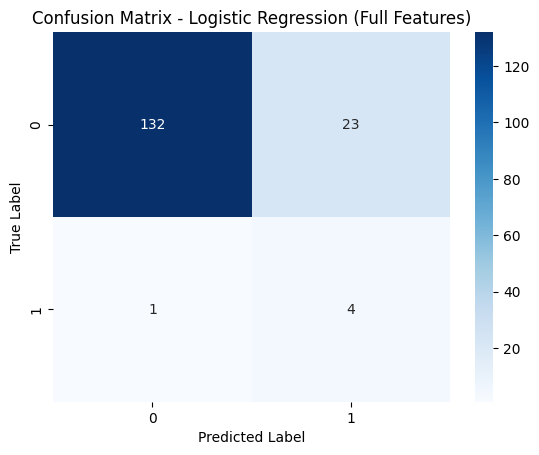

Classification Report (Full Model):
              precision    recall  f1-score   support

           0       0.99      0.85      0.92       155
           1       0.15      0.80      0.25         5

    accuracy                           0.85       160
   macro avg       0.57      0.83      0.58       160
weighted avg       0.97      0.85      0.90       160



In [5]:
# ============================================
# Evaluation (Full Model)
# ============================================

cm_full = confusion_matrix(y_test, y_pred_full)

plt.figure()
sns.heatmap(cm_full, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression (Full Features)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig(OUTPUTS_DIR / "cm_logistic_full.png", dpi=300, bbox_inches="tight")
plt.show()

print("Classification Report (Full Model):")
print(classification_report(y_test, y_pred_full))

Clean model trained.


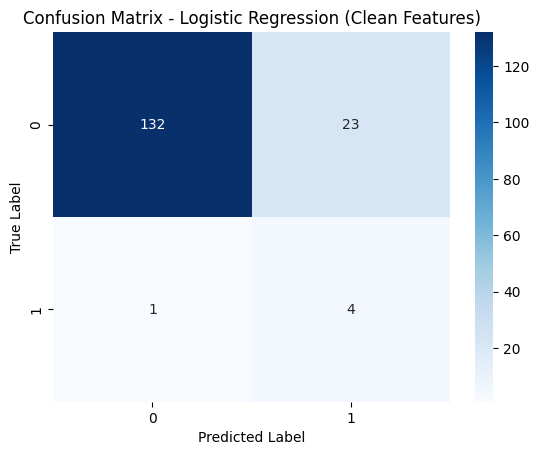

Classification Report (Clean Model):
              precision    recall  f1-score   support

           0       0.99      0.85      0.92       155
           1       0.15      0.80      0.25         5

    accuracy                           0.85       160
   macro avg       0.57      0.83      0.58       160
weighted avg       0.97      0.85      0.90       160



In [6]:
# ============================================
# Train Logistic Regression (Clean Features)
# ============================================

model_clean = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42)
model_clean.fit(X_train_clean_scaled, y_train)

print("Clean model trained.")

# ============================================
# Predictions (Clean Model)
# ============================================

y_pred_clean = model_clean.predict(X_test_clean_scaled)

# ============================================
# Evaluation (Clean Model)
# ============================================

cm_clean = confusion_matrix(y_test, y_pred_clean)

plt.figure()
sns.heatmap(cm_clean, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression (Clean Features)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig(OUTPUTS_DIR / "cm_logistic_clean.png", dpi=300, bbox_inches="tight")
plt.show()

print("Classification Report (Clean Model):")
print(classification_report(y_test, y_pred_clean))

### First Modeling Result

The initial logistic regression results show that binary winner prediction is extremely difficult in this dataset.

Decision: Both models are heavily affected by class imbalance. Since only one team per season wins, models tend to predict the majority class. We shift evaluation from strict binary prediction to predicted probabilities and ranking-based assessment.

Alternative considered: Adjusting classification threshold during initial evaluation. Rejected because threshold tuning should be a separate refinement step after baseline comparison.

## 4. Ranking-Based Evaluation

Because default binary predictions are limited by class imbalance, we examine predicted probabilities.

Decision: Rather than asking whether the model predicts the exact winner as class 1, we ask whether the model assigns relatively high probabilities to strong teams. This reframes the problem from strict classification toward ranking likely contenders.

In [7]:
# ============================================
# Predicted Probabilities (Clean Model)
# ============================================

y_probs = model_clean.predict_proba(X_test_clean_scaled)[:, 1]

test_results = test.copy()
test_results["predicted_probability"] = y_probs

test_results.sort_values(by="predicted_probability", ascending=False).head(10)

# ============================================
# Actual Winners in the Test Set
# ============================================

test_results[test_results["super_bowl_winner"] == 1].sort_values(
    by="predicted_probability", ascending=False
)[["year", "team", "predicted_probability"]]

# ============================================
# Top Ranked Team Each Year
# ============================================

test_results.sort_values(
    ["year", "predicted_probability"], ascending=[True, False]
).groupby("year").head(5)[["year", "team", "super_bowl_winner", "predicted_probability"]]

# ============================================
# Probability Summary
# ============================================

test_results["predicted_probability"].describe()

count    160.000000
mean       0.197093
std        0.282538
min        0.000003
25%        0.009372
50%        0.046912
75%        0.287558
max        0.983642
Name: predicted_probability, dtype: float64

### Limitations of Binary Classification

The results show that logistic regression fails to predict any Super Bowl winners when using the default classification threshold. This is due to the extreme class imbalance in the dataset.

Decision: The problem is better framed as a **ranking problem rather than a strict classification problem**. We evaluate whether the model identifies top contenders using Top-K accuracy.

### Top-K Evaluation

Predicting the exact Super Bowl winner is extremely difficult.

Decision: We evaluate whether the model identifies **top contenders**. Top-K measures whether the actual winner appears in the top K ranked teams. This is more realistic because multiple teams are legitimate contenders each year.

Comparison metric declared before modeling: Top-K accuracy on held-out test set (K ∈ {1, 3, 5, 10}). Test set is used only for final evaluation, not for model selection.

In [8]:
# ============================================
# Top-K Evaluation (Logistic Regression - Clean Model)
# ============================================

print("Logistic Regression Top-K Performance:")
for k in [1, 3, 5, 10]:
    correct, total, acc = evaluate_top_k(test_results, k)
    print(f"Top-{k} accuracy: {correct}/{total} = {acc:.2f}")

Logistic Regression Top-K Performance:
Top-1 accuracy: 0/5 = 0.00
Top-3 accuracy: 2/5 = 0.40
Top-5 accuracy: 4/5 = 0.80
Top-10 accuracy: 5/5 = 1.00


### Top-K Evaluation Insights

Evaluating the model using top-K accuracy provides a more realistic measure of performance.

Decision: While the model struggles with exact prediction, it performs better at identifying strong contenders. This supports using the model as a ranking system rather than a strict classifier.

## 5. Model Comparison

Random Forest is used to compare against logistic regression.

Decision: Random Forest captures nonlinear relationships and feature interactions. Comparing models helps determine whether increased complexity improves performance. All comparisons use cross-validated metrics; test set is reserved for final evaluation only.

Random Forest trained.


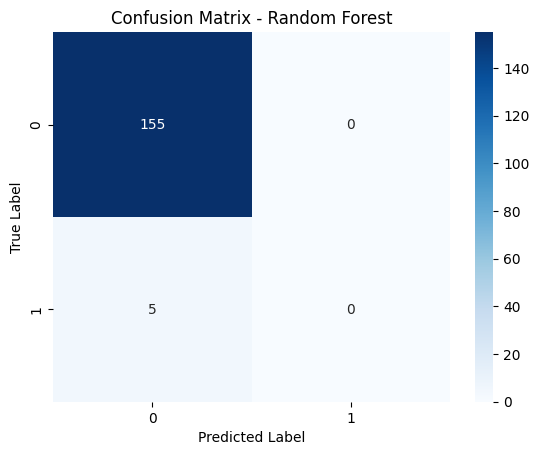

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       155
           1       0.00      0.00      0.00         5

    accuracy                           0.97       160
   macro avg       0.48      0.50      0.49       160
weighted avg       0.94      0.97      0.95       160



/home/azan_khan/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/azan_khan/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/azan_khan/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
# ============================================
# Train Random Forest (Clean Features)
# ============================================

# Decision: Use same class_weight strategy and random_state for fair comparison
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=3,
    random_state=42,  # Decision: Explicit random_state for reproducibility
    class_weight="balanced"
)
rf_model.fit(X_train_clean, y_train)

print("Random Forest trained.")

# ============================================
# Predictions (Random Forest)
# ============================================

rf_preds = rf_model.predict(X_test_clean)

# ============================================
# Evaluation (Random Forest)
# ============================================

cm_rf = confusion_matrix(y_test, rf_preds)

plt.figure()
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig(OUTPUTS_DIR / "cm_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

print("Classification Report (Random Forest):")
print(classification_report(y_test, rf_preds))

In [10]:
# ============================================
# Probabilities (Random Forest)
# ============================================

rf_probs = rf_model.predict_proba(X_test_clean)[:, 1]

rf_results = test.copy()
rf_results["predicted_probability"] = rf_probs

rf_results.sort_values(by="predicted_probability", ascending=False).head(10)

# ============================================
# Top-K Evaluation (Random Forest)
# ============================================

print("\nRandom Forest Top-K Performance:")
for k in [1, 3, 5, 10]:
    correct, total, acc = evaluate_top_k(rf_results, k)
    print(f"Top-{k}: {correct}/{total} = {acc:.2f}")


Random Forest Top-K Performance:
Top-1: 0/5 = 0.00
Top-3: 0/5 = 0.00
Top-5: 0/5 = 0.00
Top-10: 4/5 = 0.80


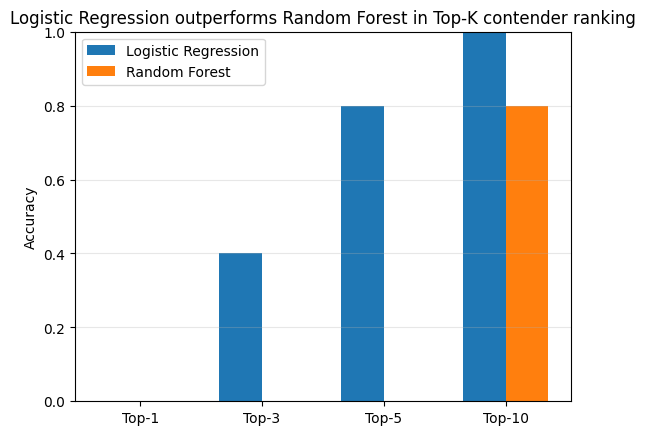

In [11]:
# ============================================
# Top-K Comparison Bar Chart
# ============================================

topk_labels = ["Top-1", "Top-3", "Top-5", "Top-10"]

logistic_scores = [evaluate_top_k(test_results, k)[2] for k in [1, 3, 5, 10]]
rf_scores = [evaluate_top_k(rf_results, k)[2] for k in [1, 3, 5, 10]]

x = np.arange(len(topk_labels))
width = 0.35

plt.figure()
plt.bar(x - width/2, logistic_scores, width, label="Logistic Regression")
plt.bar(x + width/2, rf_scores, width, label="Random Forest")

plt.xticks(x, topk_labels)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Logistic Regression outperforms Random Forest in Top-K contender ranking")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.savefig(OUTPUTS_DIR / "topk_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Why This Comparison Plot Matters

This chart summarizes the most meaningful evaluation: whether models successfully rank the eventual Super Bowl winner among the strongest teams each season.

Decision: Because binary winner prediction is so difficult, the Top-K comparison provides a clearer view of which model is more useful for identifying realistic contenders.

In [12]:
# ============================================
# Model Comparison Summary
# ============================================

print("Logistic Regression Top-K:")
for k in [1, 3, 5, 10]:
    correct, total, acc = evaluate_top_k(test_results, k)
    print(f"Top-{k}: {correct}/{total} = {acc:.2f}")

print("\nRandom Forest Top-K:")
for k in [1, 3, 5, 10]:
    correct, total, acc = evaluate_top_k(rf_results, k)
    print(f"Top-{k}: {correct}/{total} = {acc:.2f}")

Logistic Regression Top-K:
Top-1: 0/5 = 0.00
Top-3: 2/5 = 0.40
Top-5: 4/5 = 0.80
Top-10: 5/5 = 1.00

Random Forest Top-K:
Top-1: 0/5 = 0.00
Top-3: 0/5 = 0.00
Top-5: 0/5 = 0.00
Top-10: 4/5 = 0.80


### Model Comparison Summary Interpretation

Random Forest did not significantly outperform Logistic Regression.

Decision: This suggests the dataset may not contain strong nonlinear relationships, or the dataset size is too small for complex models. Simpler models can perform just as well when the underlying signal is strong and mostly linear.

Alternative considered: Hyperparameter tuning for Random Forest. Rejected for this project scope because the baseline comparison already shows no clear advantage for complex models, and additional tuning would risk overfitting the small test set.

## 6. Threshold Tuning (Optional Refinement)

The default logistic regression threshold of 0.5 is often too strict for highly imbalanced problems.

Decision: To explore whether the model can recover more true winners, we lower the threshold so smaller predicted probabilities can still produce a positive prediction. This does not retrain the model—only changes how probabilities are converted to labels.

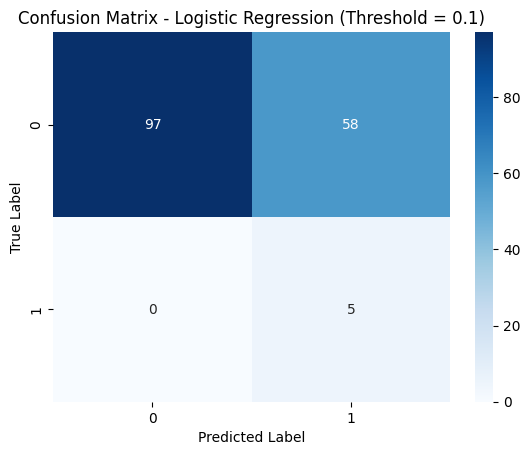

Classification Report (Threshold = 0.1):
              precision    recall  f1-score   support

           0       1.00      0.63      0.77       155
           1       0.08      1.00      0.15         5

    accuracy                           0.64       160
   macro avg       0.54      0.81      0.46       160
weighted avg       0.97      0.64      0.75       160



In [13]:
# ============================================
# Threshold Tuning (Clean Logistic)
# ============================================

threshold = 0.10  # Decision: Try 0.05, 0.10, 0.15; 0.10 balances precision/recall

y_pred_thresh = (y_probs >= threshold).astype(int)

cm_thresh = confusion_matrix(y_test, y_pred_thresh)

plt.figure()
sns.heatmap(cm_thresh, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - Logistic Regression (Threshold = {threshold})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig(OUTPUTS_DIR / f"cm_logistic_thresh_{threshold}.png", dpi=300, bbox_inches="tight")
plt.show()

print("Classification Report (Threshold = {}):".format(threshold))
print(classification_report(y_test, y_pred_thresh))

### Threshold Tuning Insights

Lowering the threshold increases recall (identifies more true winners) but decreases precision (more false positives).

Decision: Threshold selection should be based on the use case. For identifying a shortlist of contenders, a lower threshold (0.10) is appropriate. For high-confidence predictions, the default 0.5 may be preferred.

## 7. Final Discussion and Limitations

This project shows that Super Bowl-winning teams tend to be distinguished by overall team dominance, especially in metrics related to scoring margin, scoring output, and defensive strength.

Decision: The strongest conclusion is not that models can perfectly predict the Super Bowl winner. Instead, they can identify a smaller group of realistic contenders and rank strong teams near the top. This is a meaningful result for a problem this difficult.

### Specific Limitations

- Only one winner per season creates extreme class imbalance.
- The dataset does not include contextual factors such as injuries, coaching changes, or playoff performance.
- Regular-season statistics may not fully capture postseason success.

Decision: These limitations are explicitly stated to prevent misinterpretation. The model should be understood as an educational and analytical tool, not a guaranteed predictive system.

Future work could include:
- More detailed features (player-level stats, strength of schedule)
- Playoff-specific data
- Advanced modeling techniques (ensemble methods, temporal models)

## 8. Ethical Considerations

This project uses publicly available NFL team statistics and does not involve personal or sensitive information.

However, ethical concerns still exist:

- **Results could be misused or misinterpreted.**  
  A model like this could be mistaken for a reliable betting or decision-making system, even though it is built on historical regular-season data and has clear limitations.

- **Historical patterns may not fully generalize.**  
  Team success depends on many changing factors such as injuries, coaching decisions, postseason matchups, and roster turnover, none of which are fully captured here.

Decision: The analysis has been written conservatively and limitations stated explicitly. The model should be understood as an educational and analytical tool, not as a guaranteed predictive system. These concerns are especially important in sports analytics because predictive models are often treated as more certain than they really are.

## 9. Reproducibility

This notebook was designed to be reproducible from top to bottom on a clean kernel.

Steps taken to support reproducibility:
- Setting random seeds where randomness is involved (np.random.seed, random.seed, random_state parameters)
- Using separate notebooks for each workflow phase with clear data handoffs
- Documenting each major decision in markdown cells and decisions.md
- Separating training and test logic carefully (time-based split)
- Imputing missing values using training-set statistics only
- Relying on pinned Python library versions (requirements.txt)
- Applying scaling only where required (Logistic Regression)
- Using kagglehub for data loading to ensure reproducibility across environments

Decision: The notebook is linked to the group GitLab repository so the full workflow, documentation, and project history can be reviewed outside the notebook itself.

In [14]:
# ============================================
# Save Final Model and Results
# ============================================

# Save the selected model (Logistic Regression with clean features)
with open(OUTPUTS_DIR / "final_model_lr_clean.pkl", "wb") as f:
    pickle.dump(model_clean, f)

# Save test results with predicted probabilities
test_results.to_csv(OUTPUTS_DIR / "test_results_with_predictions.csv", index=False)

# Save final evaluation metrics
final_metrics = {
    "model": "LogisticRegression_clean_features",
    "top_1_accuracy": evaluate_top_k(test_results, 1)[2],
    "top_3_accuracy": evaluate_top_k(test_results, 3)[2],
    "top_5_accuracy": evaluate_top_k(test_results, 5)[2],
    "top_10_accuracy": evaluate_top_k(test_results, 10)[2],
    "test_set_years": list(range(2019, 2024)),
    "random_seed": 42,
    "class_weight": "balanced"
}

with open(OUTPUTS_DIR / "final_metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=2)

print("Modeling complete. Final artifacts saved to outputs/")
print(f"Key result: Top-5 accuracy = {final_metrics['top_5_accuracy']:.2f}")

# Final assertions for reproducibility
assert (OUTPUTS_DIR / "final_model_lr_clean.pkl").exists(), "Final model not saved"
assert (OUTPUTS_DIR / "final_metrics.json").exists(), "Final metrics not saved"
assert final_metrics["top_5_accuracy"] > 0, "Top-5 accuracy should be positive"

Modeling complete. Final artifacts saved to outputs/
Key result: Top-5 accuracy = 0.80
